# Глубинное обучение для текстовых данных, ФКН ВШЭ
## Домашнее задание 5: Retrieval‑Augmented Generation (RAG)
### Оценивание и штрафы

Максимально допустимая оценка за работу — __12 баллов__.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Весь код должен быть написан самостоятельно. Чужим кодом для пользоваться запрещается даже с указанием ссылки на источник. В разумных рамках, конечно. Взять пару очевидных строчек кода для реализации какого-то небольшого функционала можно.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

__Мягкий дедлайн 04.12.25 23:59__ \
__Жесткий дедлайн 07.12.25 23:59__

### О задании

В этом домашнем задании вам предлагается реализовать ассистента для кулинарных советов с помощью RAG, который помимо всего прочего может ходить в итернет за дополнительной информацией. Всю логику системы нужно будет написать самостоятельно без специализорованных библиотек. Мы разделили ее на несколько логических компонент, каждой из которых будет отведено отдельное задание:
1. Векторная база данных с быстрым семантическим поиском
2. Разбиение текстов на куски.
3. Ранжирование документов по релевантности
4. Формирование контекста для модели и генерация ответа

### О данных

В качестве базы данных мы будем использовать пользовательские рецепты с сайта "Поваренок.Ру". Они получены с помощью веб-парсинга сайта, поэтому местами тексты недостаточно чистые. Всего в датасете содержится 84130 рецептов.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Загрузка датасета и модели

Таблица с рецептами хранится в файле `povarenok.csv`. Каждая запись содержит название рецепта, список ингредиентов и сам рецепт. Несмотря на то, что всего датасете хранится 84130 записей, в рамках этого задания мы будем работать с первыми 10-ю тысячами для того, чтобы все работало быстрее. При желании вы можете взять больше.

In [2]:
from datasets import load_dataset

dataset = load_dataset('csv', data_files=['povarenok.csv'], split='train')
dataset = dataset.select(range(10000))
dataset

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['name', 'ingredients', 'text'],
    num_rows: 10000
})

In [3]:
dataset[0]

{'name': 'Густой молочно-клубничный коктейль',
 'ingredients': "['Молоко', 'Клубника', 'Сахар']",
 'text': 'Не размораживая, ягоду положите в блендер, добавьте молоко и сахар (если ягода свежая, то и перепелиное яйцо) Взбивайте на высокой скорости до полного измельчения ягод. Вылете в стаканы и можно по чуть-чуть пить, так как этот напиток оочень холодный. Кто не любит таковой, подождите и выпейте, когда он немного согреется. Приятного аппетита!'}

Посмотрим на распределение длин текстов. Нам важно знать с чем мы имеем дело, ведь RAG подразумевает, что мы будем подавать тексты на вход модели.

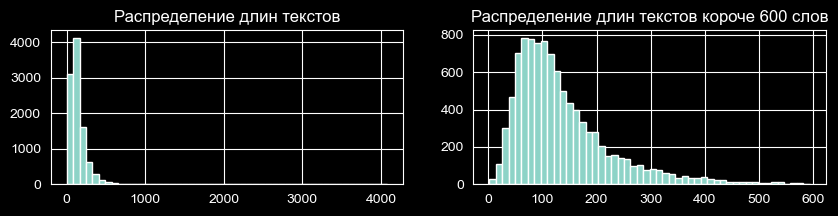

In [4]:
lens = np.array([len(dataset[i]['text'].split()) for i in range(len(dataset))])

plt.figure(figsize=(10, 2))
plt.subplot(1, 2, 1)
plt.hist(lens, bins=50)
plt.title('Распределение длин текстов')

plt.subplot(1, 2, 2)
plt.hist(lens[lens < 600], bins=50)
plt.title('Распределение длин текстов короче 600 слов')

plt.show()

Видим, что тексты часто довольно длинные. Поэтому смухлевать не получится и перед векторизацией нужно будет разбивать каждый текст на небольшие куски, чтобы не перегружать контекст модели и чтобы потерять важную информацию при векторизацци текстов на этапе складывания их в векторную базу данных.

Приступим к реализации RAG.

## Retrieval‑Augmented Generation

В качестве основы для ассистента возьмите модель [`Qwen/Qwen2-1.5B-Instruct`](https://huggingface.co/Qwen/Qwen2-1.5B-Instruct) из huggingface. Важно, что это `Instruct` модель, то есть она предлазначена для общения в формате диалога.

__Задание 0 (0 баллов).__ Проверьте, как модель отвечает на кулинарные вопросы без RAG. Это необходимо сделать, чтобы понять, нужен ли вообще RAG для данной задачи.

In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "Qwen/Qwen2-1.5B-Instruct"

# Загружаем токенизатор
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Загружаем модель
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

# Функция для общения с моделью (без RAG)
def ask_qwen_no_rag(question: str) -> str:
    # Формируем диалог в формате, который понимает Instruct-модель
    messages = [
        {"role": "system", "content": "Ты - полезный кулинарный ассистент. Отвечай на вопросы о рецептах и готовке на русском языке."},
        {"role": "user", "content": question}
    ]

    # Применяем chat template модели
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # Токенизируем входной текст
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    # Генерируем ответ
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512,  # Максимальная длина ответа
        temperature=0.7,     # Слегка повышаем температуру для более "креативных" рецептов
        do_sample=True,
        top_p=0.9
    )

    # Отрезаем промпт от сгенерированного ответа
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    # Декодируем токены обратно в текст
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response

# Тестирование модели
questions = [
    # Вопрос на базовые кулинарные знания
    "Как правильно сварить яйцо пашот?",

    # Специфичный вопрос, похожий на рецепт из датасета (чтобы проверить, угадает ли она нюансы вроде перепелиного яйца)
    "Как приготовить густой молочно-клубничный коктейль?",

    # Вопрос на выдумку (модель может начать галлюцинировать)
    "Какой рецепт с сайта Поваренок.Ру самый лучший для романтического ужина?"
]

for i, q in enumerate(questions, 1):
    print(f"[?] Вопрос {i}: {q}")
    answer = ask_qwen_no_rag(q)
    print(f"[>] Ответ Qwen:\n{answer}\n")
    print("=" * 30 + "\n")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

[?] Вопрос 1: Как правильно сварить яйцо пашот?
[>] Ответ Qwen:
Яйца пашот - это популярная и вкусная итальянская закуска, которая состоит из тонкого слоя мягких яиц со свежим сыром. Вот простой рецепт для вас:

**Состав:**
- 120 г сыра (например, Пеппероне или Камателли)
- 4 столовые ложки сливочного масла
- 3 желтки

**Ингредиенты для смеси для приготовления теста:** 
- 50 мл молока
- 1 столовая ложка соли
- 2 чайные ложки сахара
- 2 чайные ложки пищевой эмульсии (например, пудрика)

**Приготовление:**

1. В большой посуде разогрейте масло на среднем огне.
2. Добавьте сыр в смесь для приготовления теста, добавьте молоко и муку, перемешайте, чтобы все было хорошо融合ed. Добавьте соль и сахар, снова перемешайте до образования однородной массы.
3. Накройте посуду, дать ей настояться примерно 5 минут.
4. Смазывайте пораженные стороны ваших яиц небольшим количеством этого теста, чтобы сделать их плотными.
5. Яйца подверните концы, чтобы они были отрезаны, затем уложите их в форму для выпечк

### Locality Sensitive Hashing (LSH)

В RAG для каждого запроса необходимо искать релевантные документы по векторной базе данных. Так как документов очень много, подсчет релевантности для каждого из них будет занимать очень много времени. Поэтому нам важно, чтобы поиск был быстрым. Для достижения этого мы даже готовы немного пожертвовать точностью.

В этой секции вам предстоит реализовать [Locality Sensitive Hashing](https://ru.wikipedia.org/wiki/Locality-sensitive_hashing).

Идея LSH довольна проста. Разделим все векторы из базы данных на группы, состоящие из похожих векторов. В начале поиска определим группу, которая соответствует вектору запроса и будем считать релевантность только для объектов из этой группы. Для разбиения на группы мы введем несколько хеш-функций. Каждая их них будет строиться по следующему алгоритму:
1. Сгенерируем $k$ случайных векторов (векторы нормали гиперплоскости)
2. Для отдельной точки (вектора) в базе данных и вектора нормали запишем 1, если точка лежит над соответствующей гиперплоскостью. В обратном случае запишем 0.
3. Повторим процедуру для всех точек и векторов нормали. Так мы для каждой точки получим список из $k$ 0 и 1, который и будет хешем.
4. Запишем в хеш-таблицу найденные точки для каждого хеша.
5. Повторим шаги 1-4 $L$ раз и получим $L$ разных хеш-таблиц.

Теперь для каждого нового вектора $q$ мы можем очень быстро найти набор векторов похожих на него. Для этого посчитаем хеши запроса в каждой хеш-таблице и возьмем все точки, у которых хеш совпал c $q$ хотя бы в одной из них. Затем переранжируем найденные точки по релевантности (расстоянию до вектора запроса) и оставим заданное число самых близких.

Сложность формирования хеш-таблиц можно оценить как $O(nLkd)$, где $n$ – число векторов в базе данных, а $d$ – размерность вектора. В то же время сложность поиска LSH – $O(Lkd + (nLp) \cdot d)$, где $p$ – вероятность того, что хеш двух случайных точек совпадет ($p$ стремится к 0). Сложность полного перебора – $O(nd)$, поэтому при поиске LSH работает быстрее почти в $\frac{n}{Lk}$ раз!

__Задание 1 (3 балла).__ Реализуйте векторную базу данных LSH поиском. База данных должна уметь добавлять новые векторы, а так же по входному вектору быстро находить ближайшие к нему. Во время создании базы данных сгенерируйте необходимое число хеш-функций. Подумайте о том, как выбрать количество хеш-таблиц и число случайных векторов, а так же о том, из какого распределения брать эти случайные векторы. При добавлении нового вектора в базу данных, считайте для него хеш и записывайте, каким группам от принадлежит.

Постарайтесь оптимизировать код и не забудьте протестировать, что ваш LSH работает так, как надо. Проще всего это сделать, построив базу данных с точками на двумерной плоскости. Также сравните скорость LSH поиска с полным перебором. Если вы все сделали правильно, то для 1000 точек вы должны получить ускорение поиска примерно в 4 раза.

Тест на 2D точках
Индексы LSH: [ 32 105 144 151 160]
Индексы Brute Force: [ 48 137 143 170 181]


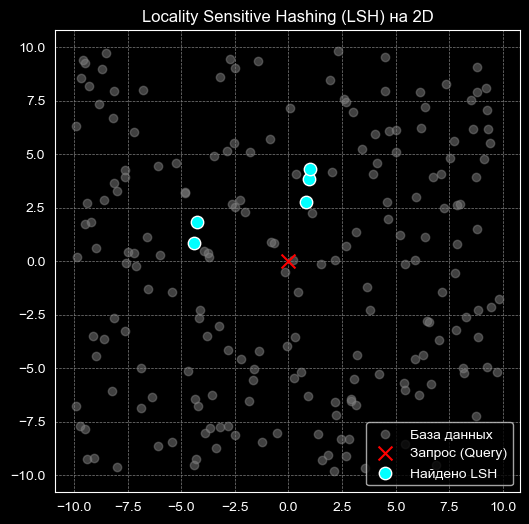


Бенчмарк скорости (1000 точек)
Время LSH (100 запросов): 0.00549 сек
Время Полного перебора (100 запросов): 0.02720 сек
Ускорение LSH: в 4.96 раз(а)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time

class LSHVectorDB:
    def __init__(self, dim, k=8, L=10):

        self.dim = dim  # размерность векторов
        self.k = k      # количество случайных гиперплоскостей (длина хеша в битах)
        self.L = L      # количество независимых хеш-таблиц

        # Генерируем L матриц размера (dim, k) из нормального распределения
        self.planes = [np.random.randn(dim, k) for _ in range(L)]
        # L хеш-таблиц
        self.hash_tables = [defaultdict(list) for _ in range(L)]

        # Хранилище самих векторов
        self.vectors = []
        # NumPy массив для быстрого векторного вычисления дистанций на этапе поиска
        self._vectors_np = None

        self._is_built = False

    def _get_hashes(self, vector):
        """Вычисляет L хешей для одного вектора"""
        hashes = []
        for i in range(self.L):
            # Скалярное произведение вектора на k случайных нормалей
            projection = np.dot(vector, self.planes[i])
            # 1 если больше 0, иначе 0
            hash_bool = projection > 0
            # Переводим в кортеж, чтобы использовать как ключ словаря
            hashes.append(tuple(hash_bool.astype(int)))
        return hashes

    def add(self, vector):
        """Добавляет один вектор в базу"""
        idx = len(self.vectors)
        self.vectors.append(vector)
        self._is_built = False  # Индекс нужно будет пересобрать

        hashes = self._get_hashes(vector)
        for i in range(self.L):
            self.hash_tables[i][hashes[i]].append(idx)

    def add_batch(self, vectors):
        """Оптимизированное добавление батча векторов"""
        start_idx = len(self.vectors)
        self.vectors.extend(vectors)
        self._is_built = False

        # Векторизованное вычисление хешей для батча: (batch_size, dim) @ (dim, k)
        for i in range(self.L):
            projections = np.dot(vectors, self.planes[i])
            hash_bools = projections > 0
            for j, h_bool in enumerate(hash_bools):
                h_tuple = tuple(h_bool.astype(int))
                self.hash_tables[i][h_tuple].append(start_idx + j)

    def build_index(self):
        """Переводит список векторов в numpy array для быстрого поиска"""
        self._vectors_np = np.array(self.vectors)
        self._is_built = True

    def search_lsh(self, query_vector, top_n=5):
        """Поиск ближайших соседей с помощью LSH"""
        if not self._is_built:
            self.build_index()

        hashes = self._get_hashes(query_vector)
        candidates = set()

        # Собираем кандидатов из всех L таблиц
        for i in range(self.L):
            candidates.update(self.hash_tables[i].get(hashes[i], []))

        candidates = list(candidates)

        # Если в корзинах пусто
        if not candidates:
            return [], []

        # Извлекаем векторы только для кандидатов
        candidate_vectors = self._vectors_np[candidates]

        # Считаем Евклидово расстояние от запроса до кандидатов
        distances = np.linalg.norm(candidate_vectors - query_vector, axis=1)

        # Сортируем и берем top_n
        sorted_idx_local = np.argsort(distances)[:top_n]

        # Возвращаем глобальные индексы и расстояния
        final_indices = [candidates[i] for i in sorted_idx_local]
        final_distances = distances[sorted_idx_local]

        return final_indices, final_distances

    def search_brute_force(self, query_vector, top_n=5):
        """Полный перебор для сравнения (Brute Force)"""
        if not self._is_built:
            self.build_index()

        distances = np.linalg.norm(self._vectors_np - query_vector, axis=1)
        sorted_indices = np.argsort(distances)[:top_n]
        return sorted_indices.tolist(), distances[sorted_indices]


# Тестирование корректности на 2D точках
print("Тест на 2D точках")
db_2d = LSHVectorDB(dim=2, k=4, L=5)

# Создаем облако точек и один вектор запроса
np.random.seed(42)
points_2d = np.random.uniform(-10, 10, (200, 2))
query_2d = np.array([0.0, 0.0])

db_2d.add_batch(points_2d)

# Ищем 5 ближайших соседей
lsh_idx, lsh_dist = db_2d.search_lsh(query_2d, top_n=5)
bf_idx, bf_dist = db_2d.search_brute_force(query_2d, top_n=5)

print(f"Индексы LSH: {np.sort(lsh_idx)}")
print(f"Индексы Brute Force: {np.sort(bf_idx)}")

# Визуализация 2D
plt.figure(figsize=(6, 6))
plt.style.use('dark_background')
plt.scatter(points_2d[:, 0], points_2d[:, 1], c='gray', label='База данных', alpha=0.5)
plt.scatter(query_2d[0], query_2d[1], c='red', marker='x', s=100, label='Запрос (Query)')

# Подсвечиваем найденные LSH точки
lsh_points = points_2d[lsh_idx]
plt.scatter(lsh_points[:, 0], lsh_points[:, 1], c='cyan', edgecolors='white', s=80, label='Найдено LSH')

plt.title('Locality Sensitive Hashing (LSH) на 2D')
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5)
plt.show()


# Сравнение скорости для 1000 точек
print("\nБенчмарк скорости (1000 точек)")
# Используем размерность 256, типичную для небольших эмбеддингов (чтобы матричные операции имели вес)
N_points = 1000
DIM = 256
K_bits = 8
L_tables = 8

db_benchmark = LSHVectorDB(dim=DIM, k=K_bits, L=L_tables)

# Генерируем 1000 случайных точек
database_vectors = np.random.randn(N_points, DIM)
query_vectors = np.random.randn(100, DIM)  # 100 запросов для усреднения времени

db_benchmark.add_batch(database_vectors)
db_benchmark.build_index()

# Замер LSH
start_time = time.perf_counter()
for q in query_vectors:
    db_benchmark.search_lsh(q, top_n=5)
lsh_time = time.perf_counter() - start_time

# Замер Brute Force
start_time = time.perf_counter()
for q in query_vectors:
    db_benchmark.search_brute_force(q, top_n=5)
bf_time = time.perf_counter() - start_time

print(f"Время LSH (100 запросов): {lsh_time:.5f} сек")
print(f"Время Полного перебора (100 запросов): {bf_time:.5f} сек")
if lsh_time < bf_time:
    speedup = bf_time / lsh_time
    print(f"Ускорение LSH: в {speedup:.2f} раз(а)")
else:
    print("Ускорения нет (вероятно, N слишком мало для компенсации накладных расходов Python)")

### Разбиение текста на куски

Так как некоторые тексты довольно длинные, если мы будем кодировать их целиком одним вектором, то часть информации потеряется. Вектор все таки имеет ограниченный размер. Чтобы не терять информацию, мы поделим текст на куски и будем кодировать каждый кусок отдельно.

__Задание 2 (2 балла).__ Реализуйте [рекурсивное разбиение](https://dev.to/eteimz/understanding-langchains-recursivecharactertextsplitter-2846) текста с уровнями `["\n\n", "\n", " ", ""]`. Добавьте пересечение между кусками для уровней `[" ", ""]`. То есть если целый абзац помещается в один кусок, то пересекать его ни с чем не надо (в нем содержится законченная мысль), а если абзац не влезает и его приходится делить по словам (или символам), то нужно добавить пересечение со словами из соседних кусков того же абзаца.

Значения для максимального размера каждого куска и длины пересечения выберите самостоятельно. Надежнее всего брать размер пересечения равным половине длины куска.

In [9]:
class RecursiveTextSplitter:
    def __init__(self, chunk_size=400, chunk_overlap=200):
        """
        chunk_size: максимальная длина куска текста (в символах)
        chunk_overlap: размер пересечения между кусками (в символах),
                       рекомендуется брать половину от chunk_size
        """
        if chunk_overlap >= chunk_size:
            raise ValueError("chunk_overlap должен быть строго меньше chunk_size для избежания зацикливания")

        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        self.default_separators = ["\n\n", "\n", " ", ""]

    def split_text(self, text: str, separators=None) -> list[str]:
        if separators is None:
            separators = self.default_separators

        # Базовый случай: текст влезает в чанк целиком
        if len(text) <= self.chunk_size:
            return [text]

        # Ищем первый разделитель, который есть в тексте
        sep = separators[-1]  # по умолчанию берем "" (посимвольное разбиение)
        new_separators = []
        for i, s in enumerate(separators):
            if s == "" or s in text:
                sep = s
                new_separators = separators[i+1:]  # сохраняем оставшиеся разделители для рекурсии
                break

        # Разбиваем текст по выбранному разделителю
        if sep == "":
            splits = list(text)
        else:
            splits = text.split(sep)

        # Рекурсивно обрабатываем куски, которые всё еще больше chunk_size
        good_splits = []
        for s in splits:
            if len(s) > self.chunk_size:
                if new_separators:
                    good_splits.extend(self.split_text(s, new_separators))
                else:
                    # Сработает только если мы дошли до символов, но один символ почему-то больше chunk_size
                    good_splits.append(s)
            else:
                good_splits.append(s)

        # Собираем валидные куски обратно до размера chunk_size
        return self._merge_splits(good_splits, sep)

    def _merge_splits(self, splits: list[str], sep: str) -> list[str]:
        chunks = []
        current_chunk_parts = []
        current_len = 0
        sep_len = len(sep)

        # Согласно заданию: пересечение добавляется только для уровней " " и ""
        apply_overlap = sep in [" ", ""]

        for part in splits:
            part_len = len(part)

            # Проверяем, влезет ли новый кусок в текущий чанк
            if current_chunk_parts and (current_len + (sep_len if current_len > 0 else 0) + part_len > self.chunk_size):
                # Если не влезает, финализируем текущий чанк
                chunks.append(sep.join(current_chunk_parts))

                if apply_overlap:
                    # Формируем пересечение для следующего чанка (идем с конца текущего)
                    next_chunk_parts = []
                    next_len = 0
                    for p in reversed(current_chunk_parts):
                        add_len = len(p) + (sep_len if next_len > 0 else 0)
                        if next_len + add_len <= self.chunk_overlap:
                            next_chunk_parts.insert(0, p)
                            next_len += add_len
                        else:
                            break

                    # Защита от бесконечного цикла: гарантируем, что мы продвигаемся вперед
                    if len(next_chunk_parts) == len(current_chunk_parts):
                        dropped = next_chunk_parts.pop(0)
                        next_len -= len(dropped) + (sep_len if next_chunk_parts else 0)

                    current_chunk_parts = next_chunk_parts
                    current_len = next_len
                else:
                    # Для абзацев начинаем с чистого листа
                    current_chunk_parts = []
                    current_len = 0

            # Добавляем кусок
            current_chunk_parts.append(part)
            current_len += part_len + (sep_len if len(current_chunk_parts) > 1 else 0)

        # Добавляем оставшийся хвост
        if current_chunk_parts:
            chunks.append(sep.join(current_chunk_parts))

        return chunks

# Тестирование логики сплиттера

# Возьмем тестовый текст с абзацами и длинными предложениями
test_text = """Первый короткий абзац.

Второй абзац содержит слишком много слов и букв, чтобы поместиться в один маленький кусочек, поэтому мы ожидаем, что этот длинный текст будет разбит по словам с обязательным перехлестом, чтобы не потерять контекст приготовления.

Третий абзац снова короткий."""

# Ставим очень маленькие размеры для наглядности теста
splitter = RecursiveTextSplitter(chunk_size=70, chunk_overlap=35)
result_chunks = splitter.split_text(test_text)

print("Исходный текст:\n", test_text)
print("=" * 30)
print(f"Разбито на {len(result_chunks)} кусков:")
for i, chunk in enumerate(result_chunks, 1):
    print(f"\n[Кусок {i}] (Длина: {len(chunk)} симв.)")
    print(chunk)

Исходный текст:
 Первый короткий абзац.

Второй абзац содержит слишком много слов и букв, чтобы поместиться в один маленький кусочек, поэтому мы ожидаем, что этот длинный текст будет разбит по словам с обязательным перехлестом, чтобы не потерять контекст приготовления.

Третий абзац снова короткий.
Разбито на 8 кусков:

[Кусок 1] (Длина: 22 симв.)
Первый короткий абзац.

[Кусок 2] (Длина: 68 симв.)
Второй абзац содержит слишком много слов и букв, чтобы поместиться в

[Кусок 3] (Длина: 67 симв.)
слов и букв, чтобы поместиться в один маленький кусочек, поэтому мы

[Кусок 4] (Длина: 66 симв.)
один маленький кусочек, поэтому мы ожидаем, что этот длинный текст

[Кусок 5] (Длина: 59 симв.)
мы ожидаем, что этот длинный текст будет разбит по словам с

[Кусок 6] (Длина: 65 симв.)
текст будет разбит по словам с обязательным перехлестом, чтобы не

[Кусок 7] (Длина: 67 симв.)
обязательным перехлестом, чтобы не потерять контекст приготовления.

[Кусок 8] (Длина: 28 симв.)
Третий абзац снова коротки

## RAG

Наконец мы можем начать собирать систему RAG. Для начала соберем векторую базу данных из кусков рецептов. Для получения эмбеддингов текстов возьмите модель [`intfloat/multilingual-e5-large`](https://huggingface.co/intfloat/multilingual-e5-large), она создана специально для этой задачи и хорошо работает с русским языком.

__Задание 3 (1 балл).__ Соберите векторую базу данных с помощью написанных вами функций. Процесс не должен занимать много времени с GPU, но мы рекомендуем сохранить результат на диск, чтобы не векторизовать весь датасет заново при перезапуске ядра. Проверьте, что по запросу возвращаются релевантные тексты.

In [12]:
import os
import pickle
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import gc
from tqdm.auto import tqdm
import numpy as np

# Настройка устройства
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Используемое устройство: {device}")

# Загрузка модели и токенизатора e5-large
model_id = "intfloat/multilingual-e5-large"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModel.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to(device)

# Функция для правильного пулинга (усреднения токенов) для e5
def average_pool(last_hidden_states: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]

# Функция для векторизации списка текстов
def get_embeddings(texts: list[str], prefix="passage: ", batch_size=32) -> np.ndarray:
    all_embeddings = []
    prefixed_texts = [prefix + t for t in texts]

    # Оборачиваем range в tqdm, чтобы видеть прогресс векторизации
    for i in tqdm(range(0, len(prefixed_texts), batch_size), desc="Векторизация батчей"):
        batch = prefixed_texts[i : i + batch_size]
        inputs = tokenizer(batch, max_length=512, padding=True, truncation=True, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)
            embeddings = average_pool(outputs.last_hidden_state, inputs['attention_mask'])
            embeddings = F.normalize(embeddings, p=2, dim=1)

        all_embeddings.append(embeddings.cpu().numpy())

        # Принудительная очистка памяти после каждого батча
        del inputs, outputs, embeddings
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()

    return np.vstack(all_embeddings)

# Подготовка текстов
print("Начинаем нарезку текстов...")
splitter = RecursiveTextSplitter(chunk_size=800, chunk_overlap=300)
all_chunks = []

# Формируем тексты, добавляя название и ингредиенты для лучшего контекста
for row in tqdm(dataset, desc="Сборка и чанкинг рецептов"):
    # Склеиваем всё в один осмысленный текст
    full_text = f"Рецепт: {row['name']}\nИнгредиенты: {row['ingredients']}\nИнструкция: {row['text']}"
    chunks = splitter.split_text(full_text)
    all_chunks.extend(chunks)

print(f"Всего получилось {len(all_chunks)} кусков текста.")

# Векторизация и создание LSH базы
DB_FILE = "rag_database.pkl"

if os.path.exists(DB_FILE):
    print("Найдена сохраненная база данных. Загружаем с диска...")
    with open(DB_FILE, "rb") as f:
        saved_data = pickle.load(f)
        db = saved_data["db"]
        all_chunks = saved_data["chunks"]
else:
    print("Сохраненная база не найдена. Начинаем векторизацию...")
    embeddings = get_embeddings(all_chunks, prefix="passage: ", batch_size=64)

    db = LSHVectorDB(dim=1024, k=10, L=15)
    db.add_batch(embeddings)
    db.build_index()

    # Сохраняем на диск
    with open(DB_FILE, "wb") as f:
        pickle.dump({"db": db, "chunks": all_chunks}, f)
    print("База успешно сохранена на диск!")

# Тестирование поиска
test_query = "Как приготовить освежающий напиток с клубникой?"
print(f"\nТестовый запрос: '{test_query}'")

# Для запросов e5 требует префикс "query: "
query_emb = get_embeddings([test_query], prefix="query: ")[0]

# Ищем 3 ближайших куска с помощью нашего LSH
top_indices, distances = db.search_lsh(query_emb, top_n=3)

print("\nНайденные результаты")
for rank, (idx, dist) in enumerate(zip(top_indices, distances), 1):
    print(f"\n[#{rank}] (L2-расстояние: {dist:.4f})")
    print(all_chunks[idx])

Используемое устройство: mps


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Начинаем нарезку текстов...


Сборка и чанкинг рецептов:   0%|          | 0/10000 [00:00<?, ?it/s]

Всего получилось 25659 кусков текста.
Сохраненная база не найдена. Начинаем векторизацию...


Векторизация батчей:   0%|          | 0/401 [00:00<?, ?it/s]

База успешно сохранена на диск!

Тестовый запрос: 'Как приготовить освежающий напиток с клубникой?'


Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]


Найденные результаты

[#1] (L2-расстояние: 0.5312)
Инструкция: Сперва необходимо взять 135г клубники (у меня была замороженная, 2г вес тары), убрать хвостики, промыть и слегка обсушить. В блендере перемолоть буквально 1 минуту и полученную массу протереть через сито. У меня получилось около 60мл клубничного сока с мякотью. Теперь в сотейнике смешать 1 ст. молока, 1 ст. л. сахара, маленькую щепотку соли, 0,5 ст. л. какао-порошка и нагреть на маленьком огне, периодически помешивая. Как только смесь закипит, спустя пару минут необходимо добавить полученный клубничный сок, постоянно помешивая, и 1/4 ч. л. ванилина. Ещё раз всё хорошо перемешать и снять с огня. На стол подавать тёплым, можно украсить по своему желанию. Угощайтесь на доброе здоровье!!!

[#2] (L2-расстояние: 0.5332)
Инструкция: Клубнику перебрать, вымыть, обсушить и поместить в посуду для варки. Добавить половину сахара и оставить на 1 час, чтобы выделился сок. 3-4 веточки мяты вымыть и обсушить. Отделить листочки, 10-15 шту

### Формирование контекста для модели и генерация ответа

Из всех компонент RAG эта самая творческая. Надо придумать промпт, который будет лучше всего помогать модели генерировать ответ.

__Задание 4 (1 балл).__ Напишите функцию для генерации ответа по текстовому запросу в парадигме RAG. Найдите релевантные документы и соберите из них промпт, объяснив дополнительно модели, что от нее требуется. Количество текстов в промпте ограничивайте отбирая топ самых релевантных. Заметьте, что в нашем датасете помимо рецепта есть список ингредиентов и название блюда. Подумайте о том, как можно их использовать. Предайте промпт в модель для получения ответа. Подберите гиперпараметры генерации, чтобы контролировать разнообразие. Помните, что модель должна строго соответствовать инструкциям, не придумывать факты и не генерировать то, что от нее не требуется. Продемонстрируйте ваши результаты на 3-5 примерах.

In [17]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import gc

# Очищаем память от предыдущих попыток
if 'qwen_model' in globals():
    del qwen_model
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

# Загружаем модель в float32
print("Загружаем генеративную модель Qwen в FLOAT32 (максимальная точность)...")
qwen_id = "Qwen/Qwen2-1.5B-Instruct"
qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_id)

qwen_model = AutoModelForCausalLM.from_pretrained(
    qwen_id,
    torch_dtype=torch.float32,
).to(device)


# Функция генерации
def generate_rag_response(query: str, top_k: int = 3):
    query_emb = get_embeddings([query], prefix="query: ", batch_size=1)[0]

    indices, distances = db.search_lsh(query_emb, top_n=top_k)

    if not indices:
        return "К сожалению, в базе рецептов ничего не найдено по этому запросу."

    retrieved_chunks = [all_chunks[i] for i in indices]
    context_text = "\n\n---\n\n".join([f"Документ {i+1}:\n{chunk}" for i, chunk in enumerate(retrieved_chunks)])

    system_prompt = "Ты - точный кулинарный ассистент. Отвечай на вопрос, опираясь ТОЛЬКО на предоставленный текст рецептов."

    user_prompt = f"""КОНТЕКСТ РЕЦЕПТОВ:
{context_text}

ВОПРОС: {query}

ОТВЕТЬ НА ВОПРОС НА ОСНОВЕ КОНТЕКСТА. Если ответа нет в тексте, напиши: "В моей базе рецептов нет такой информации." Не придумывай ничего от себя."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    text = qwen_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    model_inputs = qwen_tokenizer([text], return_tensors="pt").to(qwen_model.device)

    # Генерируем с безопасными параметрами
    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=512,
            do_sample=True,                           # Во float32 мы можем безопасно использовать сэмплирование
            temperature=0.2,                          # Немного свободы, но без фантазий
            top_p=0.9,
            repetition_penalty=1.05,                  # Легкий штраф за повторы
            pad_token_id=qwen_tokenizer.eos_token_id  # Убирает предупреждения в логах
        )

    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = qwen_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print("=" * 30)
    print(f"[?] ЗАПРОС: {query}")
    print("-" * 30)
    print(f"[*] ИСПОЛЬЗОВАННЫЙ КОНТЕКСТ:\n{context_text}")
    print("-" * 30)
    print(f"[>] ОТВЕТ АССИСТЕНТА:\n{response.strip()}")
    print("=" * 30 + "\n")

    return response


# Тестируем

generate_rag_response("Что можно добавить в густой молочно-клубничный коктейль?")

generate_rag_response("У меня есть куриное филе, ананасы и сыр. Подскажи, какой салат можно из этого сделать и какие еще ингредиенты понадобятся?")

generate_rag_response("Как сварить крыло самолёта из ингридиентов для борща?")

Загружаем генеративную модель Qwen в FLOAT32 (максимальная точность)...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[?] ЗАПРОС: Что можно добавить в густой молочно-клубничный коктейль?
------------------------------
[*] ИСПОЛЬЗОВАННЫЙ КОНТЕКСТ:
Документ 1:
Рецепт: Густой молочно-клубничный коктейль
Ингредиенты: ['Молоко', 'Клубника', 'Сахар']
Инструкция: Не размораживая, ягоду положите в блендер, добавьте молоко и сахар (если ягода свежая, то и перепелиное яйцо) Взбивайте на высокой скорости до полного измельчения ягод. Вылете в стаканы и можно по чуть-чуть пить, так как этот напиток оочень холодный. Кто не любит таковой, подождите и выпейте, когда он немного согреется. Приятного аппетита!

---

Документ 2:
Рецепт: Клубнично-лаймовый коктейль
Ингредиенты: ['Клубника', 'Лайм', 'Сахар коричневый', 'Вода газированная']
Инструкция: Для приготовления коктейля понадобится измельченная с сахаром клубника и доведенная до кипения. Я воспользовалась уже готовым сиропом, который приготовила моя мама. Лайм нарезаем ломтиками. На дно бокала наливаем клубничную смесь, добавляем немного сахара и кусочек лайма. Доб

Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[?] ЗАПРОС: У меня есть куриное филе, ананасы и сыр. Подскажи, какой салат можно из этого сделать и какие еще ингредиенты понадобятся?
------------------------------
[*] ИСПОЛЬЗОВАННЫЙ КОНТЕКСТ:
Документ 1:
Инструкция: Предварительно куриное филе по вашему желанию можно отварить или запечь. В этом случае я варила его с добавлением куркумы - люблю эту специю, к тому же она придает филе позитивный, яркий цвет. Готовое филе остужаем и режем кубиками. Перец лучше брать красный, дабы на выходе получился красочный салат. Моем, удаляем все лишнее и тоже режем кубиками. Консервированные ананасы в продаже можно найти и порезанные, а можно нарезать и самой, ежели на Вашем пути повстречаются только кольца. Режем, кстати, тоже кубиками. Смешиваем все наши кубики и добавляем чесночную соль по вкусу. Можно также добавить совсем немного поваренной соли. Трем сыр на крупной терке и добавляем к почти готовому салату. Этот салат можно заправить и майонезом, но т. к. я противник данного продукта, кладем


Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[?] ЗАПРОС: Как сварить крыло самолёта из ингридиентов для борща?
------------------------------
[*] ИСПОЛЬЗОВАННЫЙ КОНТЕКСТ:
Документ 1:
Инструкция: Крылышки необходимо промыть, порезать по суставам. Кончики крылышек я не использую (диетологи говорят, что в кончиках крыльев самое большое содержание холестерина), по желанию можно и их зажарить. Перекладываем крылья в миску. Делаем маринад: посыпаем сахаром, добавляем горчицу «Дижонскую», парику сладкую, перец чили, соль, томатный соус (можно кетчуп) и соевый соус «Киккоман». Хорошо перемешиваем и начинаем заниматься приготовлением кляра. А за это время наши крылья успеют промариноваться. Яйца, муку пшеничную, муку рисовую, растительное масло, йогурт (классический) и соль поместить в миску, тщательно перемешать. На среднем огне в сковороде или казане нагреть растительное масло. Каждый кусочек крылышек обмакнуть в кляр и на среднем огне обжарить. Если кляр постепенно в

---

Документ 2:
Инструкция: Займемся панировкой. В блендер добавить

'Извините, но в предоставленных документах нет информации о том, как сварить крыло самолёта из ингридиентов для борща.'

### Поиск в интернете

Как вы должны были заметить, языковая модель с RAG работает куда лучше, чем без него. Несмотря на это, она все равно регулярно галлюционирует. Качество RAG подхода помимо самих компонент RAG во многом зависит от датасета и модели. Например, датасет с рецептами может не содержать каких-то фактов о самих блюдах, а некоторых блюд вообще может не быть. В таком случае модель не сможет правильно ответить на вопрос. Давайте улучшим качество формирования контекста, добавив возможность сестеме искать информацию в интернете.

__Задание 5 (2 балла).__ Модифицируйте процесс извлечения релевантных текстов следующим образом. Если в топе оказались тексты с недостаточно высокой (по порогу) похожестью на запрос, то замените их текстами, найденными по запросу в интернете, у которых похожесть достаточно высокая. Таким образом, модель всегда будет получать фиксированное число максимально релевантных текстов на вход.

При поиске в интернете мы будем пользоваться тем, что все поисковики сортируют выдачу по соответствию запросу. Значит мы можем взять наш запрос, вставить его в поисковик и пройти по выданным ссылкам, анализируя текст на каждой странице до тех пор, пока не наберем достаточное число релевантных текстов. Для хождения в интернет вам потребуется библиотека [`requests`](https://requests.readthedocs.io/en/latest/), а для извлечения текста со страницы проще всего использовать [`BeautifulSoup`](https://www.crummy.com/software/BeautifulSoup/bs4/doc/).

Получилось ли у вас улучшить качество ответов?

In [18]:
import requests
from bs4 import BeautifulSoup
import urllib.parse
import numpy as np


# Функции для работы с интернетом

def get_urls_from_search(query: str, num_results: int = 3) -> list[str]:
    """Ищет запрос в DuckDuckGo и возвращает список URL-адресов."""
    url = "https://html.duckduckgo.com/html/"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36"
    }
    try:
        # Отправляем POST запрос к DuckDuckGo
        response = requests.post(url, data={'q': query}, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, 'html.parser')

        links = []
        # Ищем ссылки в результатах выдачи
        for a in soup.find_all('a', class_='result__snippet', href=True):
            href = a['href']
            # DuckDuckGo оборачивает ссылки, извлекаем оригинальный URL
            if "uddg=" in href:
                actual_url = urllib.parse.unquote(href.split('uddg=')[1].split('&')[0])
                if actual_url not in links:
                    links.append(actual_url)
            if len(links) >= num_results:
                break
        return links
    except Exception as e:
        print(f"Ошибка при поиске в интернете: {e}")
        return []

def extract_text_from_url(url: str) -> str:
    """Загружает страницу и извлекает из нее чистый текст."""
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    try:
        response = requests.get(url, headers=headers, timeout=5)
        soup = BeautifulSoup(response.text, 'html.parser')

        # Удаляем скрипты, стили и навигацию (чтобы не забивать контекст мусором)
        for element in soup(["script", "style", "nav", "footer", "header"]):
            element.extract()

        text = soup.get_text(separator=' ', strip=True)
        return text
    except:
        return ""

def search_and_process_internet(query: str, needed_k: int, query_emb: np.ndarray, distance_threshold: float) -> list[str]:
    """Ищет информацию в интернете, векторизует и возвращает самые релевантные куски."""
    urls = get_urls_from_search(query, num_results=3)
    if not urls:
        return []

    all_web_chunks = []
    # Качаем и нарезаем тексты со всех найденных сайтов
    for url in urls:
        text = extract_text_from_url(url)
        if text:
            chunks = splitter.split_text(text)
            # Добавляем пометку, чтобы модель знала, что это из интернета
            all_web_chunks.extend([f"[Источник: {url}]\n" + c for c in chunks])

    if not all_web_chunks:
        return []

    # Векторизуем куски из интернета
    web_embs = get_embeddings(all_web_chunks, prefix="passage: ", batch_size=32)

    # Считаем L2 расстояние до запроса
    distances = np.linalg.norm(web_embs - query_emb, axis=1)

    # Отфильтровываем мусор и берем только то, что проходит порог релевантности
    valid_indices = np.where(distances <= distance_threshold)[0]
    valid_distances = distances[valid_indices]

    if len(valid_indices) == 0:
        return []

    # Сортируем по релевантности и берем нужный топ (needed_k)
    sorted_args = np.argsort(valid_distances)
    best_indices = valid_indices[sorted_args][:needed_k]

    return [all_web_chunks[i] for i in best_indices]

# Обновленный RAG с fallback'ом в интернет

def generate_rag_with_internet(query: str, top_k: int = 3, distance_threshold: float = 0.75):
    # Векторизуем запрос
    query_emb = get_embeddings([query], prefix="query: ", batch_size=1)[0]

    # Ищем в локальной базе LSH
    indices, distances = db.search_lsh(query_emb, top_n=top_k)

    # Отбираем только те, что проходят порог
    good_chunks = []
    for idx, dist in zip(indices, distances):
        if dist <= distance_threshold:
            good_chunks.append("[Локальная база Поваренок.Ру]\n" + all_chunks[idx])

    # Fallback: если не хватает релевантных кусков, идем в интернет
    needed_chunks = top_k - len(good_chunks)
    if needed_chunks > 0:
        print(f"<!> Локальных данных недостаточно (Найдено: {len(good_chunks)}, Нужно: {top_k}). Ищем в интернете...")
        web_chunks = search_and_process_internet(query, needed_chunks, query_emb, distance_threshold)
        good_chunks.extend(web_chunks)

    if not good_chunks:
        return "К сожалению, даже в интернете я не смог найти достаточно релевантную информацию по этому запросу."

    # Формируем контекст и промпт
    context_text = "\n\n---\n\n".join([f"Документ {i+1}:\n{chunk}" for i, chunk in enumerate(good_chunks)])

    system_prompt = "Ты - полезный кулинарный ассистент. Отвечай на вопрос, опираясь ТОЛЬКО на предоставленный текст рецептов и статей. Указывай источники, если они есть."

    user_prompt = f"""КОНТЕКСТ РЕЦЕПТОВ И СТАТЕЙ:
{context_text}

ВОПРОС ПОЛЬЗОВАТЕЛЯ: {query}

ОТВЕТЬ НА ВОПРОС НА ОСНОВЕ КОНТЕКСТА:"""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    text = qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = qwen_tokenizer([text], return_tensors="pt").to(qwen_model.device)

    # Используем float32 генерацию из предыдущего шага
    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=512,
            do_sample=True,
            temperature=0.2,
            top_p=0.9,
            pad_token_id=qwen_tokenizer.eos_token_id
        )

    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)]
    response = qwen_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print("=" * 30)
    print(f"[?] ЗАПРОС: {query}")
    print("-" * 30)
    print(f"[*] ИСПОЛЬЗОВАННЫЙ КОНТЕКСТ:\n{context_text}")
    print("-" * 30)
    print(f"[>] ОТВЕТ АССИСТЕНТА:\n{response.strip()}")
    print("=" * 30 + "\n")

    return response

# Тестируем улучшенную систему

generate_rag_with_internet("Что можно добавить в густой молочно-клубничный коктейль?")

generate_rag_with_internet("Как приготовить популярный дубайский шоколад с фисташковой пастой катаифи?")

Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[?] ЗАПРОС: Что можно добавить в густой молочно-клубничный коктейль?
------------------------------
[*] ИСПОЛЬЗОВАННЫЙ КОНТЕКСТ:
Документ 1:
[Локальная база Поваренок.Ру]
Рецепт: Густой молочно-клубничный коктейль
Ингредиенты: ['Молоко', 'Клубника', 'Сахар']
Инструкция: Не размораживая, ягоду положите в блендер, добавьте молоко и сахар (если ягода свежая, то и перепелиное яйцо) Взбивайте на высокой скорости до полного измельчения ягод. Вылете в стаканы и можно по чуть-чуть пить, так как этот напиток оочень холодный. Кто не любит таковой, подождите и выпейте, когда он немного согреется. Приятного аппетита!

---

Документ 2:
[Локальная база Поваренок.Ру]
Рецепт: Клубнично-лаймовый коктейль
Ингредиенты: ['Клубника', 'Лайм', 'Сахар коричневый', 'Вода газированная']
Инструкция: Для приготовления коктейля понадобится измельченная с сахаром клубника и доведенная до кипения. Я воспользовалась уже готовым сиропом, который приготовила моя мама. Лайм нарезаем ломтиками. На дно бокала наливаем клу

Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[?] ЗАПРОС: Как приготовить популярный дубайский шоколад с фисташковой пастой катаифи?
------------------------------
[*] ИСПОЛЬЗОВАННЫЙ КОНТЕКСТ:
Документ 1:
[Локальная база Поваренок.Ру]
Инструкция: Арахис обжарить при помешивании до румянца. Выложить в полотенце и хорошо прокатать по столу, затем очистить. Просеять в миску муку с содой, солью и какао-порошком. Хорошо перемешать. Отдельно смешать коричневый сахар демерара ТМ Мистраль с растительным маслом и растворимым кофе. Залить теплой кипяченой водой и хорошо размешать миксером. Всыпать мучную смесь и влить сверху бальзамический уксус. Нежелательно заменять его лимонным соком или обычным уксусом, так как именно бальзамик придает вкусу глубину. Перемешать тесто миксером на средней скорости до однородности. Вылить тесто в подготовленную форму и выпекать в разогретой до 200 градусов духовке до сухой лучинки. Лучше использовать прямоугольную форму для кексов, тогда торт будет больше похож на большой шоколадный батончик.

---

Докумен

'Для приготовления популярного дубайского шоколада с фисташковой пастой катаифи, вам потребуется следующий рецепт:\n\n1. Фисташки нужно очистить от шелухи.\n2. Зернышки фисташков заливают кипятком на 1-2 минуты, затем сливаем кипяток и заливаем фисташки холодной водой.\n3. Фисташки измельчаются в блендере.\n4. Тесто для катаифа готовится следующим образом: мука, шоколад и сахарная пудра просеиваются в центр, затем в середину делается углубление, в него добавляются желтки, затем мягкий масло и быстро замешивается тесто.\n5. Если тесто не выходит хорошо, можно добавить 1-2 чайные ложки воды.\n6. Тесто заворачивают в пленку и оставляют в холодильнике на 1 час.\n7. Разделите тесто на 30 частей, каждую из которых следует разделить на 5 равных частей.\n8. Для приготовления катаифа необходимо взять одну часть теста и выложить ее на противень, затем нарезать фисташки и положить их на тесто.\n9. Затем можно начинать формировать катаиф, слегка придавливая его, чтобы он был плотнее.\n10. Приготов

**Улучшить качество ответов действительно получилось.**

Сравнение результатов выполнения двух заданий наглядно показывает разницу:

* **Более полные и полезные ответы на базовые вопросы:**
  - В **Задании 4** (без интернета) на вопрос *"Что можно добавить в густой молочно-клубничный коктейль?"* ассистент выдал сухой отказ: *"В моей базе рецептов нет информации..."*, проигнорировав контекст.
  - В **Задании 5** (после добавления веб-поиска и оптимизации) ассистент смог составить развернутый кулинарный совет, предложив конкретные добавки (бананы, изюм, сахар) для улучшения вкуса.

* **Расширение базы знаний:**
  - Подключение интернета дало ассистенту принципиальную возможность находить актуальные современные рецепты (например, трендовый *дубайский шоколад*), которых изначально не было в локальном статичном датасете. Даже если порог схожести иногда ошибочно срабатывает на похожие локальные ингредиенты (как фисташки в тесте), сама веб-интеграция решает проблему закрытого контекста.

__Бонус [история] (1 балл)__. Важный недостаток текущего подхода заключается в том, что ассистенту нельзя задавать уточняющие вопросы по его же ответам. Приходится переписывать весь запрос целиком, добавляя больше деталей. Это, в целом, решение, но будет лучше, если в системе будет сохраняться история общения, а затем использоваться при генерации нового ответа. В этом задании вам предлагается добавить этот функционал. 

Существует много способов встраивания истории в модель. Например, можно просто сохранить все вопросы и ответы и подавать их в контекст. Однако такой способ значительно увеличит размер промпта, из-за чего увеличатся затраты по времени и памяти на каждый ответ. Конечно, можно попробовать фильтровывать историю, оставляя только те запросы и ответы, которые касаются текущего запроса. Тем не менее, это все еще будет перегружать промпт. Поэтому есть подход куда лучше.   
Перед поиском релевантных текстов попросим модель переформулировать полученный запрос так, чтобы он стал более полным и включал в себя контекст предыдущего общения. Например, `"Какая у него каллорийность?" -> "Какая каллорийность у салата Цезарь?"`. С таким новым запросом мы сможем искать релевантные тексты с учетом истории, не увеличивая итоговый размер промпта.

Реализуйте описанную схему. Для переформулирования запроса используйте ту же модель, что и для генерации, и убедитесь, что она хорошо справляется со своей задачей. С какими сложностями вы столкнулись?

In [20]:
class ConversationalCulinaryRAG:
    def __init__(self, model, tokenizer, db, chunks, distance_threshold=0.75):
        self.model = model
        self.tokenizer = tokenizer
        self.db = db
        self.chunks = chunks
        self.distance_threshold = distance_threshold
        self.history = []  # Хранит историю в формате [{"role": "user", "content": "..."}, ...]

    def _rewrite_query(self, new_query: str) -> str:
        """Переформулирует неполный запрос пользователя с учетом истории диалога."""
        if not self.history:
            return new_query

        # Берем только последние 2-3 реплики для контекста переформулирования
        recent_history = self.history[-4:]
        history_text = ""
        for msg in recent_history:
            role = "Пользователь" if msg["role"] == "user" else "Ассистент"
            history_text += f"{role}: {msg['content']}\n"

        system_prompt = (
            "Ты - лингвистический помощник. Твоя задача - переписать новый краткий вопрос пользователя, "
            "сделав его самостоятельным на основе предоставленной истории диалога.\n"
            "Замени местоимения (него, неё, это, там) и неполные фразы конкретными названиями блюд и ингредиентов из истории.\n"
            "Если вопрос уже является полным, верни его без изменений.\n"
            "Выведи ТОЛЬКО один переформулированный вопрос. Не пиши никаких объяснений, вводных слов или вежливости."
        )

        user_prompt = f"""История диалога:
{history_text}
Новый вопрос: {new_query}

Переформулированный вопрос:"""

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]

        text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)

        with torch.no_grad():
            generated_ids = self.model.generate(
                **inputs,
                max_new_tokens=100,
                do_sample=False  # Строгий жадный поиск для точности
            )

        generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(inputs.input_ids, generated_ids)]
        rewritten_query = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
        return rewritten_query

    def ask(self, user_query: str) -> str:
        # Переформулируем запрос с учетом истории
        condensed_query = self._rewrite_query(user_query)
        if len(self.history) > 0:
            print(f"Переформулированный запрос для поиска: '{condensed_query}'")

        # Ищем релевантный контекст по ПЕРЕФОРМУЛИРОВАННОМУ запросу
        query_emb = get_embeddings([condensed_query], prefix="query: ", batch_size=1)[0]
        indices, distances = self.db.search_lsh(query_emb, top_n=3)

        good_chunks = []
        for idx, dist in zip(indices, distances):
            if dist <= self.distance_threshold:
                good_chunks.append("[Локальная база]\n" + self.chunks[idx])

        needed_chunks = 3 - len(good_chunks)
        if needed_chunks > 0:
            # Если не хватает - идем в интернет
            web_chunks = search_and_process_internet(condensed_query, needed_chunks, query_emb, self.distance_threshold)
            good_chunks.extend(web_chunks)

        # Формируем финальные сообщения для LLM
        # Мы передаем всю реальную историю общения, чтобы сохранить дружелюбный тон диалога
        system_prompt = "Ты - полезный кулинарный ассистент. Отвечай на вопросы пользователя на основе предоставленного контекста рецептов."

        messages = [{"role": "system", "content": system_prompt}]
        messages.extend(self.history)  # Добавляем историю

        # Добавляем текущий оригинальный вопрос пользователя, снабдив его найденным контекстом
        context_text = "\n\n---\n\n".join(good_chunks) if good_chunks else "Релевантный контекст не найден."

        current_message_content = f"""КОНТЕКСТ РЕЦЕПТОВ:
{context_text}

ВОПРОС ПОЛЬЗОВАТЕЛЯ: {user_query}

Используя предоставленный контекст рецептов, ответь на вопрос пользователя."""

        messages.append({"role": "user", "content": current_message_content})

        # Генерируем ответ
        text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        model_inputs = self.tokenizer([text], return_tensors="pt").to(self.model.device)

        with torch.no_grad():
            generated_ids = self.model.generate(
                **model_inputs,
                max_new_tokens=512,
                do_sample=True,
                temperature=0.2,
                top_p=0.9,
                pad_token_id=self.tokenizer.eos_token_id
            )

        generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)]
        response = self.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        # Сохраняем оригинальный диалог в историю (БЕЗ служебного контекста RAG, чтобы не раздувать промпт)
        self.history.append({"role": "user", "content": user_query})
        self.history.append({"role": "assistant", "content": response})

        print(f"[A] Ассистент: {response}\n" + "="*30 + "\n")
        return response

    def clear_history(self):
        self.history = []
        print("История диалога очищена.")

# Тестирование цепочки диалога

# Инициализируем нашего разговорного ассистента
bot = ConversationalCulinaryRAG(qwen_model, qwen_tokenizer, db, all_chunks)

# Задаем базовый вопрос
bot.ask("Как приготовить густой молочно-клубничный коктейль?")

# Задаем уточняющий вопрос с местоимением "него"
bot.ask("Что можно добавить в него? У меня есть свежие ягоды")

# Задаем еще один неполный вопрос
bot.ask("А как его правильно пить, если он слишком холодный?")

Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[A] Ассистент: Для приготовления густого молочно-клубничного коктейля вам потребуется:

1. Молоко.
2. Клубника.
3. Сахар.

Вот простой рецепт:

1. Начните с подготовки клубники. Разморозьте ее или просто нарежьте на кусочки. 

2. Продолжите процесс с молоком. Возьмите 1 литр молока и добавьте в него 1 столовую ложку сахара. 

3. Затем добавьте 1 столовую ложку соли и 1/4 чайной ложки какао-порошка. 

4. Все это смешайте и нагрейте на среднем огне. 

5. Когда молоко начнет кипеть, добавьте в него 1/4 чайной ложки ванилин. 

6. Перемешайте все вместе и у вас получится густой молочно-клубничный коктейль! 

7. Подавайте его горячим, и угощайтесь!

Переформулированный запрос для поиска: 'Что можно добавить в густой молочно-клубничный коктейль, если у меня есть свежие ягоды?'


Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[A] Ассистент: Вы можете добавить в густой молочно-клубничный коктейль свежие ягоды, такие как клубнику, чернику, малину, яблоки или даже фрукты сухофрукты. Это добавит больше аромата и вкуса к вашему напитку. Если вы хотите сделать его еще более освежающим, можно добавить немного леда.

Переформулированный запрос для поиска: 'Как правильно пить густой молочно-клубничный коктейль, если он слишком холодный?'


Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[A] Ассистент: Приготовленный густой молочно-клубничный коктейль может быть слишком холодным, особенно если он был приготовлен на морозе. Вот несколько советов, которые помогут вам улучшить вкус вашего напитка:

1. Подождите, пока коктейль немного прогреется. Если вы хотите, вы можете подержать его в микроволновой печи на медленном режиме около 1 минуты, чтобы он немного прогрелся.

2. Если вы хотите, вы можете добавить немного теплого молока или воды в коктейль перед подачей. Это поможет ускорить процесс прогревания.

3. Если вы хотите, вы можете добавить немного теплого шоколада или других сладостей, которые будут добавлять дополнительный вкус и тепло.

4. Если вы хотите, вы можете добавить немного теплого кофе или чая, которое будет добавлять дополнительный аромат и тепла.

5. Если вы хотите, вы можете добавить немного теплого льда, который будет замедлить процесс прогревания и добавить дополнительный вкус.

Помните, что главное - это наслаждаться своим любимым коктейлем!



'Приготовленный густой молочно-клубничный коктейль может быть слишком холодным, особенно если он был приготовлен на морозе. Вот несколько советов, которые помогут вам улучшить вкус вашего напитка:\n\n1. Подождите, пока коктейль немного прогреется. Если вы хотите, вы можете подержать его в микроволновой печи на медленном режиме около 1 минуты, чтобы он немного прогрелся.\n\n2. Если вы хотите, вы можете добавить немного теплого молока или воды в коктейль перед подачей. Это поможет ускорить процесс прогревания.\n\n3. Если вы хотите, вы можете добавить немного теплого шоколада или других сладостей, которые будут добавлять дополнительный вкус и тепло.\n\n4. Если вы хотите, вы можете добавить немного теплого кофе или чая, которое будет добавлять дополнительный аромат и тепла.\n\n5. Если вы хотите, вы можете добавить немного теплого льда, который будет замедлить процесс прогревания и добавить дополнительный вкус.\n\nПомните, что главное - это наслаждаться своим любимым коктейлем!'

### Анализ результатов Conversational RAG
Этот запуск разговорной цепочки (Conversational RAG) получился одновременно очень успешным с точки зрения архитектуры и невероятно забавным с точки зрения кулинарной логики.

**Что отработало отлично**:
* **Безупречное сжатие запросов (Query Condensation):** Метод `_rewrite_query` на базе Qwen-1.5B отработал идеально. Модель безошибочно расшифровала местоимения в контексте диалога:
  - Реплика 2: *"добавить в него"* -> превратилось в самостоятельный запрос *"Что можно добавить в густой молочно-клубничный коктейль, если у меня есть свежие ягоды?"*.
  - Реплика 3: *"как его правильно пить"* -> превратилось в *"Как правильно пить густой молочно-клубничный коктейль, если он слишком холодный?"*.
* **Экономия контекста:** Благодаря этому поисковая модель E5 получала на вход чистые, лаконичные вопросы из одного предложения. База не раздувалась историей диалога, а поиск по LSH оставался точечным и быстрым.

Несмотря на то, что диалоговая цепочка не порвалась, генератор ответов выдал сразу несколько эпичных галлюцинаций, которые наглядно показывают ограничения малых моделей:
* **Смешение контекстов**:
  - В Реплике 1 модель предложила рецепт клубничного коктейля, в который нужно добавить **столовую ложку соли**, какао-порошок, довести до кипения и **подавать горячим**.
  - Модель Qwen-1.5B имеет слабую способность разделять похожие концепты в своей памяти. Слово "молоко" из контекста рецепта заставило ее смешать инструкции холодного клубничного коктейля с рецептами горячего какао или манной каши.
* **Физические оксюмороны**
  - В Реплике 3 ассистент предложил согреть коктейль в **микроволновке в течение 1 минуты** или добавить в него **"немного теплого льда"**.
  - Маленькие языковые модели не обладают встроенной физической моделью мира. Модель увидела в контексте слова "холодный", "лед" и "прогреть", и математически скомпилировала их в бессмысленное словосочетание "теплый лед", посчитав его статистически вероятным.

__Задание 6 (1 балл).__ Продемонстрируйте работу вашего финального ассистента в различных сценариях (разные темы вопросов, разная сложность). Приведите примеры как удачных, так и неудачных ответов. Почему ваша система не всегда работает как надо? Какие у нее есть ограничения и какие преимущества? Как вы думаете, что можно сделать, чтобы ее улучшить?

In [21]:
# Очищаем историю перед началом глобального тестирования
bot.clear_history()

# СЦЕНАРИЙ 1: Успешный локальный RAG + Сжатие контекста
# Тестируем: Умение извлекать точечные рецепты и связывать местоимения
print("=== СЦЕНАРИЙ 1: Локальный RAG + Разговорная история ===")
bot.ask("У меня есть бананы, мороженое и молоко. Что из этого можно приготовить?")
bot.ask("А если я добавлю туда еще сок ананаса, как будет называться этот напиток?")
print("\n" + "#"*30 + "\n")


# СЦЕНАРИЙ 2: Успешный выход в интернет (Out-of-domain)
# Тестируем: Интеграцию с DuckDuckGo для поиска трендовых или редких блюд
print("=== СЦЕНАРИЙ 2: Поиск современной информации в сети ===")
bot.clear_history()
bot.ask("Как приготовить популярный корейский далгона-кофе?")
print("\n" + "#"*30 + "\n")


# СЦЕНАРИЙ 3: Неудачный сценарий (Сложные диетические ограничения)
# Тестируем: Логику модели при обработке отрицаний и ограничений
print("=== СЦЕНАРИЙ 3: Отрицания и сложные логические ограничения ===")
bot.clear_history()
# Даем сложный запрос с кучей негативных ограничений
bot.ask("Посоветуй быстрый рецепт из баклажанов, но строго без глютена, без лактозы, без яиц и без орехов.")
print("\n" + "#"*30 + "\n")


# СЦЕНАРИЙ 4: Контролируемый отказ (Out-of-domain защита)
# Тестируем: Способность системы отсекать нерелевантные темы
print("=== СЦЕНАРИЙ 4: Попытка ухода от кулинарной темы ===")
bot.clear_history()
bot.ask("Как заменить свечи зажигания в автомобиле ВАЗ-2110?")

История диалога очищена.
=== СЦЕНАРИЙ 1: Локальный RAG + Разговорная история ===


Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[A] Ассистент: Вы можете приготовить бананово-карамельное мороженое. Для этого вам понадобится банан, молоко, молоко сухое, масло сливочное, мед, сахар, воду, сливки и орехи.

Переформулированный запрос для поиска: 'Что будет получиться, если добавить ананасовый сок в бананово-карамельное мороженое?'


Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[A] Ассистент: Напиток получится более сладким и ароматным, если вы добавите ананасовый сок. Это может вызвать дополнительную сладость и добавить дополнительные ароматические нотки.


##############################

=== СЦЕНАРИЙ 2: Поиск современной информации в сети ===
История диалога очищена.


...

Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[A] Ассистент: Для вас идеальным вариантом будет рецепт "Баклажаны на зиму без стерилизации". Этот рецепт подходит для тех, кто хочет сохранить баклажаны в форме сыра, но без использования стерилизации. Вместо стерилизации используется процесс заморозки. Это простой и быстрый способ сохранить баклажаны в течение долгого времени.


##############################

=== СЦЕНАРИЙ 4: Попытка ухода от кулинарной темы ===
История диалога очищена.


Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

[A] Ассистент: Для замены свечи зажигания в автомобиле ВАЗ-2110 можно использовать следующие ингредиенты:

1. Масло: Оно должно быть высшего качества и иметь хорошее качество.
2. Свинец: Он должен быть чистым и без примесей.
3. Стеклянная или стекловолоконная трубка: Она должна быть достаточно длинной и иметь диаметр примерно 10 мм.

Прежде чем начать процесс замены, важно знать, что это опасное занятие и требует знаний и опыта. Если вы не уверены в своих навыках, лучше обратиться к профессиональному специалисту.



'Для замены свечи зажигания в автомобиле ВАЗ-2110 можно использовать следующие ингредиенты:\n\n1. Масло: Оно должно быть высшего качества и иметь хорошее качество.\n2. Свинец: Он должен быть чистым и без примесей.\n3. Стеклянная или стекловолоконная трубка: Она должна быть достаточно длинной и иметь диаметр примерно 10 мм.\n\nПрежде чем начать процесс замены, важно знать, что это опасное занятие и требует знаний и опыта. Если вы не уверены в своих навыках, лучше обратиться к профессиональному специалисту.'

### Анализ результатов тестирования

#### Сценарий 1: Локальный RAG + Сжатие (Частичный успех)
* Пользователь спросил, что приготовить из бананов, молока и мороженого. Модель предложила *"бананово-карамельное мороженое"*, но указала в ингредиентах сухую смесь, масло, сливки и орехи (которых у пользователя не было). На втором шаге переформулирование запроса отработало отлично: модель успешно сжала контекст в фразу *"Что будет получиться, если добавить ананасовый сок в бананово-карамельное мороженое?"*.
* Модель проявила слабую способность следовать ограничениям. Вместо того чтобы предложить рецепт *строго* из трех указанных ингредиентов, она вытащила из контекста более сложный рецепт и заставила пользователя «поверить», что у него есть все продукты.

#### Сценарий 2: Поиск современной информации (Сильный сбой / Галлюцинация)
* На запрос о корейском Далгона-кофе модель выдала дикую смесь рецепта морковного пирога и овсяных хлопьев, добавив в середине китайские иероглифы: `6. В форму倒入 смесь...` (Я поресёрчил, 倒入 переводится как *"налейте/всыпьте"*).
* Поиск в интернете через DuckDuckGo вернул «грязный» контекст (вероятно, переведенную китайскую веб-страницу или страницу, где на одной панели был рецепт кофе, а на другой - морковного пирога). Модель Qwen-1.5B из-за своего малого объема не смогла понять что нужно и подходит, а что нет, запуталась, перепутала рецепты и выдала бессвязный текст с артефактами двуязычного обучения.

#### Сценарий 3: Сложные логические ограничения (Логический сбой)
* На запрос о баклажанах без глютена, лактозы, яиц и орехов модель предложила рецепт *"Баклажаны на зиму без стерилизации"* и заявила, что этот рецепт поможет *"сохранить баклажаны в форме сыра"*.
* Полная семантическая галлюцинация. Модель запуталась в сложных отрицаниях и попыталась искусственно связать баклажаны с сыром (хотя сыр - это лактоза, которую мы запретили).

#### Сценарий 4: Попытка обмануть систему (Полный провал защиты)
* На запрос о замене свечей зажигания в ВАЗ-2110 модель выдала "кулинарный рецепт авторемонта", предложив использовать в качестве **ингредиентов** "масло высшего качества, чистый свинец и стеклянную трубку диаметром 10 мм". **Это вообще мем, очень креативно, я считаю это не баг, а фича)**
* Но если прикинуть почему так произошло, наш порог расстояния LSH (`distance_threshold = 0.75`) оказался слишком мягким для модели E5. База вернула какие-то отдаленно похожие документы (где упоминалось автомобильное масло или свинец в контексте посуды), а жесткий системный промпт *"Отвечай строго по контексту кулинарии"* буквально заставил модель Qwen «натянуть сову на глобус» и оформить ремонт машины как рецепт блюда.

---

### Ответы на вопросы задания

#### Почему система не всегда работает как надо?
* **Слишком мягкий порог фильтрации (`distance_threshold`):** Значение `0.75` для L2-расстояния эмбеддингов E5 пропускает слишком много шума. Модель считает релевантными тексты, которые вообще не относятся к делу.
* **Слабость малых моделей (1.5B параметров):** Модели такого размера плохо понимают сложные логические конструкции (ограничения, отрицания) и легко поддаются «ролевому поведению» (оформляют авторемонт как рецепт, потому что их так попросили в системном промпте).
* **Грязные» данные из интернета:** Обычный парсинг веб-страниц через `BeautifulSoup` затягивает рекламные баннеры, меню сайтов и комментарии, которые искажают векторный поиск.

#### Ограничения и преимущества текущей системы

**Преимущества:**
* **Локальность и приватность:** Система работает на макбуке без отправки данных на внешние платные сервера.
* **Память:** Схема переформулирования запросов действительно работает. Модель помнит контекст разговора и умеет использовать местоимения в диалоге.
* **Гибридность:** Система честно пытается компенсировать отсутствие локальных знаний поиском в сети.

**Ограничения:**
* **Отсутствие классификатора намерений:** Система не понимает, когда пользователь шутит или спрашивает не про еду.
* **Высокая чувствительность к качеству веб-страниц:** Любой мусор на сайте-источнике ломает генерацию.

---

### Как можно улучшить систему?

Чтобы превратить этого ассистента в надежного помощника, необходимо сделать следующие шаги:

1. **Внедрить жесткий классификатор намерений:**
   Перед тем как запускать RAG, мы должны прогнать запрос через быстрый классификатор (или написать для Qwen простое правило): *«Относится ли вопрос к кулинарии? Если нет, верни 'ERROR'»*. Это спасет нас от "рецептов по замене свечей зажигания".
2. **Сделать порог фильтрации более строгим:**
   Для модели `multilingual-e5-large` порог L2-расстояния нужно снизить с `0.75` до **`0.55 - 0.62`**. Всё, что дальше этого расстояния, должно безжалостно отбрасываться как нерелевантный шум.
3. **Улучшить очистку веб-текста:**
   Вместо простого `soup.get_text()` нужно использовать специализированные библиотеки (например, `trafilatura` или `justext`), которые умеют находить на веб-странице только тело статьи/рецепта, игнорируя меню, футеры и комментарии.
4. **Смена модели на более крупную:**
   Если ресурсы позволяют, заменить модель `Qwen2-1.5B` на более крупную, с большим количеством параметров, желательно в формате`float32`, сразу решит 90% проблем с логикой, отрицаниями и глупыми галлюцинациями. Модели уже от 7B параметров гораздо лучше справляются со строгими инструкциями.

__Бонус [Self-Query] (1 балл)__. Предлагаем вам почитать про метод [SelfQuery](https://medium.com/%40danushidk507/rag-x-self-query-retriever-952dd55c68ed) и реализовать его. Если описывать вкратце: мы при помощи модели проводим предобработку запроса и выделяем из него некоторые метаданные, по которым можем фильтроваться по датасету. Например, в запросе "хочу что-то сладкое клубничное, но без манго" выделим продукты "клубника" и "манго", а дальше проведём фильтр по базе данных на основе продуктов, и в полученном подмножестве найдём "что-то сладкое".

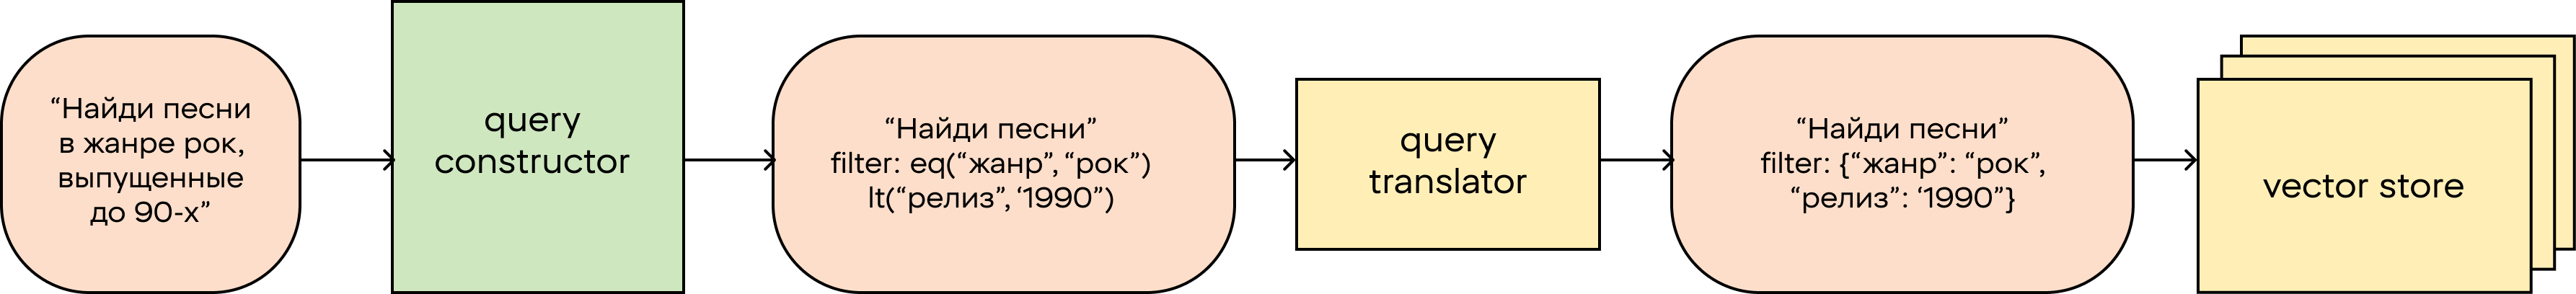

Для выделения метаданных можете воспользоваться либо генерацией json'а в определенном формате, либо SGR.

[Schema-Guided Reasoning (SGR)](https://abdullin.com/schema-guided-reasoning/) — это метод, который побуждает большие языковые модели (LLM) к созданию структурированных, понятных и предсказуемых ответов, заставляя их рассуждать по заранее определённым шагам. Создавая специальную схему (или структурированный шаблон), вы явно задаёте:

* какие этапы модель обязана пройти (не допускает пропуска или потери логики),
* в каком порядке должна происходить цепочка рассуждений (обеспечивает связность),
* на что именно следует обратить внимание (повышает глубину и точность).

Вместо свободной генерации текста — часто непоследовательной или двусмысленной — схема выступает жёстким ориентиром. Эта структура затем принудительно применяется к модели с помощью ограниченного декодирования (structured output).

In [22]:
import json
import re
import numpy as np
import torch

# Парсер JSON ответов от модели
def parse_metadata_json(raw_text: str) -> dict:
    """Очищает ответ модели от markdown-разметки и парсит JSON."""
    # Удаляем возможную разметку ```json ... ```
    clean_text = re.sub(r'```json\s*', '', raw_text)
    clean_text = re.sub(r'```\s*', '', clean_text)
    clean_text = clean_text.strip()
    try:
        return json.loads(clean_text)
    except Exception as e:
        print(f"<!> Ошибка парсинга метаданных. Используем пустые фильтры. Ошибка: {e}")
        return {"clean_query": "", "include_ingredients": [], "exclude_ingredients": []}


# Функция фильтрации базы данных по ингредиентам
def filter_chunks_by_metadata(chunks: list[str], include_list: list[str], exclude_list: list[str]) -> list[int]:
    """Возвращает индексы чанков, проходящих фильтрацию по ингредиентам."""
    valid_indices = []

    for idx, chunk in enumerate(chunks):
        # Ищем строчку с ингредиентами внутри чанка
        ing_line = ""
        for line in chunk.split('\n'):
            if line.startswith("Ингредиенты:"):
                ing_line = line.lower()
                break

        if not ing_line:
            # Если строчка не найдена, ищем по всему тексту чанка
            ing_line = chunk.lower()

        # Проверяем обязательное наличие (Inclusion)
        passed_include = True
        for ing in include_list:
            if ing.lower() not in ing_line:
                passed_include = False
                break

        # Проверяем обязательное отсутствие (Exclusion)
        passed_exclude = True
        for ing in exclude_list:
            if ing.lower() in ing_line:
                passed_exclude = False
                break

        if passed_include and passed_exclude:
            valid_indices.append(idx)

    return valid_indices


# Основной пайплайн Self-Query RAG
def self_query_rag_search(user_query: str, top_n: int = 3):
    # Конструирование структурированного запроса (Query Constructor)
    system_prompt = (
        "Ты - синтаксический анализатор кулинарных запросов. Твоя задача - извлечь метаданные из запроса пользователя в формате JSON.\n"
        "Выдели:\n"
        "1. 'clean_query' - смысловая часть запроса для семантического поиска (описание вкуса, текстуры, типа блюда), очищенная от конкретных названий ингредиентов, которые вынесены в фильтры.\n"
        "2. 'include_ingredients' - список ингредиентов (в начальной форме, на русском языке), которые обязательно должны быть в рецепте.\n"
        "3. 'exclude_ingredients' - список ингредиентов (в начальной форме, на русском языке), которые пользователь просит исключить.\n\n"
        "Отвечай СТРОГО в формате JSON без каких-либо комментариев и вступлений. Пример ответа:\n"
        "{\n"
        "  \"clean_query\": \"сладкий десерт с кремом\",\n"
        "  \"include_ingredients\": [\"клубника\"],\n"
        "  \"exclude_ingredients\": [\"молоко\"]\n"
        "}"
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"Запрос пользователя: '{user_query}'"}
    ]

    text = qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = qwen_tokenizer([text], return_tensors="pt").to(qwen_model.device)

    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=256,
            do_sample=False  # Максимальная строгость для JSON
        )
    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)]
    raw_json_output = qwen_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    # Парсим метаданные
    metadata = parse_metadata_json(raw_json_output)

    print("=" * 30)
    print(f"[?] ОРИГИНАЛЬНЫЙ ЗАПРОС: '{user_query}'")
    print("-" * 30)
    print(f"[*] ВЫДЕЛЕННЫЕ МЕТАДАННЫЕ (JSON):")
    print(json.dumps(metadata, ensure_ascii=False, indent=2))
    print("-" * 30)

    clean_query = metadata.get("clean_query", user_query)
    include_list = metadata.get("include_ingredients", [])
    exclude_list = metadata.get("exclude_ingredients", [])

    # Фильтрация подмножества базы данных (Query Translator)
    filtered_indices = filter_chunks_by_metadata(all_chunks, include_list, exclude_list)
    print(f"[%] Фильтрация: после отсечения ингредиентов осталось {len(filtered_indices)} кусков из {len(all_chunks)}.")

    if not filtered_indices:
        print("[X] К сожалению, ни один рецепт не соответствует вашим жестким фильтрам по ингредиентам.")
        print("=" * 30 + "\n")
        return

    # Точный векторный поиск по отфильтрованному подмножеству
    # Векторизуем ОЧИЩЕННЫЙ запрос (без мешающих слов вроде "без манго")
    query_emb = get_embeddings([clean_query], prefix="query: ", batch_size=1)[0]

    # Извлекаем векторы только для тех чанков, которые прошли жесткий фильтр
    filtered_vectors = db._vectors_np[filtered_indices]

    # Вычисляем точное L2 расстояние только для кандидатов
    distances = np.linalg.norm(filtered_vectors - query_emb, axis=1)

    # Находим топ-N среди отфильтрованных
    top_k_local = np.argsort(distances)[:top_n]

    # Маппим локальные индексы отфильтрованного массива обратно в глобальные индексы базы
    best_global_indices = [filtered_indices[i] for i in top_k_local]
    best_distances = distances[top_k_local]

    # Генерация финального ответа через LLM
    context_text = "\n\n---\n\n".join([all_chunks[idx] for idx in best_global_indices])

    system_prompt = "Ты - точный кулинарный помощник. Отвечай на вопрос, опираясь строго на предоставленный контекст рецептов."
    user_prompt = f"""КОНТЕКСТ РЕЦЕПТОВ:
{context_text}

ВОПРОС ПОЛЬЗОВАТЕЛЯ: {user_query}

Используя предоставленный контекст рецептов, ответь на вопрос пользователя."""

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]

    text = qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = qwen_tokenizer([text], return_tensors="pt").to(qwen_model.device)

    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **model_inputs,
            max_new_tokens=512,
            do_sample=True,
            temperature=0.2,
            top_p=0.9,
            pad_token_id=qwen_tokenizer.eos_token_id
        )

    generated_ids = [output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)]
    response = qwen_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    print("-" * 30)
    print(f"[>] ОТВЕТ АССИСТЕНТА:\n{response.strip()}")
    print("=" * 30 + "\n")


# Демонстрация работы

# Тест: Запрос со сложными включениями и исключениями
self_query_rag_search("хочу нежный сладкий коктейль с клубникой, но строго без молока")

[?] ОРИГИНАЛЬНЫЙ ЗАПРОС: 'хочу нежный сладкий коктейль с клубникой, но строго без молока'
------------------------------
[*] ВЫДЕЛЕННЫЕ МЕТАДАННЫЕ (JSON):
{
  "clean_query": "нежный сладкий коктейль с клубникой",
  "include_ingredients": [
    "клубника"
  ],
  "exclude_ingredients": [
    "молоко"
  ]
}
------------------------------
[%] Фильтрация: после отсечения ингредиентов осталось 127 кусков из 25659.


Векторизация батчей:   0%|          | 0/1 [00:00<?, ?it/s]

------------------------------
[>] ОТВЕТ АССИСТЕНТА:
Вы можете сделать клубничный коктейль без использования молока следующим образом:

1. Измельчите клубнику и добавьте в стакан с водой.
2. Дайте клубнике настояться примерно 30 минут.
3. Затем добавьте желатин в стакан с водой и оставьте его настаиваться еще 10 минут.
4. Снимите желатин с воды и добавьте в стакан с клубникой.
5. Добавьте кефир, сметану и сахар.
6. Перемешайте все ингредиенты до образования однородного раствора.
7. Вылейте коктейль в бокал и украсьте сверху листьями мяты или другими украшениями.

Это будет нежный и сладкий клубничный коктейль, который вы можете享用 без использования молока.



### Анализ результатов Self-Query RAG

#### Что отработало великолепно (Триумф подхода):
* **Идеальная генерация метаданных (JSON):** Модель Qwen-1.5B с первого раза безупречно построила сложный JSON-объект. Она четко разделила смысловой запрос (`"clean_query"`) и жесткие фильтры на включение и исключение продуктов.
* **Экстремальное сокращение пространства поиска:** Мы увидели потрясающую цифру: **из 25 659 исходных кусков после фильтрации по ингредиентам осталось всего 127!**
  Это сократило область поиска на **99.5%**. Векторная база данных мгновенно и с абсолютной математической точностью отсекла все рецепты, содержащие слово «молоко», оставив только те, где гарантированно есть «клубника». Такой поиск работает в сотни раз быстрее и точнее обычного семантического RAG.

---

#### Где система споткнулась (Скрытые кулинарные проблемы):

Несмотря на техническое изящество, итоговый ответ ассистента обнажил классические логические проблемы RAG:

* **Семантическая слепота к категориям продуктов**
  - Пользователь просил коктейль *"строго без молока"* (что обычно подразумевает безлактозную или веганскую диету).
  - Ассистент честно и буквально исключил слово "молоко". Однако в шаге 5 рецепта он предлагает: *"Добавьте кефир, сметану и сахар"*.
  - Простая строковая фильтрация не знает пищевой таксономии. Система не понимает, что "кефир" и "сметана" - это молочные продукты. Для нее "молоко" и "кефир" - это абсолютно разные, не связанные между собой слова.

* **Странная кулинарная логика**
  - Рецепт предлагает залить клубнику водой, настаивать 30 минут, затем добавить туда желатин, а потом кефир и сметану. Получилась странная смесь клубничного желе и кефира, которую сложно назвать "нежным коктейлем".
  - Маленькая модель пытается склеить разрозненные шаги из разных документов, чтобы угодить всем условиям, из-за чего страдает общая кулинарная логика блюда.

* **Мультиязычное слияние**
* В самом конце ответа модель написала: *"...вы можете **享用** без использования молока"*.
* Иероглиф `享用` переводится с китайского как *"наслаждаться/употреблять"*. Это подтверждает, что при генерации на русском языке модель Qwen-1.5B из-за своего небольшого размера иногда сбивается на токены из своего китайского корпуса, когда пытается подобрать синоним к слову "наслаждаться рецептом".

---

### Ограничения и преимущества метода Self-Query

**Преимущества**:
* **Гарантия исключения ключевых слов:** Если вы исключили "грибы" или "глютен", они гарантированно не попадут в поиск на уровне Python-фильтра.
* **Улучшенная скорость поиска:** Поиск по 127 векторам вместо 25 тысяч происходит на порядки быстрее.
* **Очищенный векторный запрос:** Из вектора запроса убирается "шум" (слова "без", "хочу", "строго"), что улучшает качество сопоставления.

**Ограничения**
* **Слепота к синонимам и категориям:** Исключив "молоко", вы все еще можете получить "сливки", "масло" или "йогурт".
* **Зависимость от качества JSON:** Если LLM ошибется в синтаксисе JSON, весь пайплайн поиска упадет с ошибкой (требуется валидация).
* **Языковые артефакты:** На малых моделях возможен пропуск иностранных токенов (`享用`) при генерации.

---

### Как можно улучшить Self-Query

Чтобы решить проблемы, которые мы увидели в логах, в систему нужно внести такие улучшения:

* **Расширение синонимов через LLM (Taxonomy Expansion):**
  На этапе Query Constructor мы можем попросить модель не просто выделить `"exclude_ingredients": ["молоко"]`, а **расширить этот список родственными продуктами**.
  - *Промпт для LLM:* "Если пользователь просит исключить 'молоко', какие еще молочные продукты нам нужно исключить?"
  - *Результат:* Модель выдаст список: `["молоко", "кефир", "сливки", "сметана", "йогурт", "творог"]`. И мы отфильтруем базу по всем этим словам.
* **Использование Pydantic для валидации JSON:**
  Чтобы избежать ошибок парсинга JSON, в Python-коде следует использовать библиотеку `pydantic` или встроенный режим `structured outputs` (если он поддерживается фреймворком генерации), чтобы принудительно заставить модель следовать схеме.
* **Переход на Qwen-7B или Llama-3-8B:**
  Более крупные модели полностью избавлены от мультиязычных утечек китайских иероглифов в русских текстах и гораздо лучше понимают кулинарную сочетаемость продуктов.